#Introducción  

Se realiza el análisis del "Medical Insurance Dataset" disponible en Kaggle, utilizando modelos de redes neuronales. Luego, se comparan los resultados con modelos de regresión lineal, logarítmica y polinómica.

El conjunto de datos incluye información detallada sobre los costos del seguro médico para diferentes individuos y contiene las siguientes variables:

* Edad: Edad de la persona asegurada.
* Sexo: Género del asegurado, categorizado como masculino o femenino.
* Índice de Masa Corporal (BMI): Medida que asocia el peso y la altura de una persona para evaluar si se encuentra en un rango de peso saludable.
* Número de hijos: La cantidad de hijos que tiene el asegurado.
* Tabaquismo: Estado de fumador del asegurado, categorizado como fumador o no fumador.
* Región: Área geográfica donde reside el asegurado, dividida en diferentes regiones.
* Cargos incurridos: El costo total de las primas de seguro médico que el asegurado ha pagado o que se espera pagar.
Objetivo del Análisis

El objetivo principal de este análisis es identificar y comprender los factores que influyen en las primas de seguro médico. Al analizar estas variables, se espera poder estimar el costo del seguro para diferentes individuos, teniendo en cuenta su perfil demográfico y salud.

Este análisis es crucial para las compañías de seguros, porque les permite ajustar sus políticas y primas de acuerdo con el riesgo asociado a diferentes grupos de personas. Además, los resultados pueden ser útiles para los consumidores que buscan comprender cómo se calculan sus primas y qué factores pueden estar afectando sus costos de seguro.

# Paso 1: Cargue de datos


In [6]:
# Cargar datos de Medical Insurance Dataset (kaggle.com)
# Datos tomados de: https://www.kaggle.com/datasets/orhfusion/medical-insurance-dataset?resource=download

import pandas as pd
import numpy as np
import chardet

# Detectar la codificación del archivo
with open('Medical Insurance Dataset.csv', 'rb') as file:
    result = chardet.detect(file.read(10000))  # Leer una parte del archivo para detectar la codificación
    print("codificación del archivo:",result['encoding'])

# Determinar el número total de líneas en el archivo
with open('Medical Insurance Dataset.csv', 'r', encoding=result['encoding']) as file:
    total_lines = sum(1 for line in file)

# Crear una lista de índices de filas a omitir
# En este caso no fue necesario
skip_rows = []

# Lee el archivo omitiendo la línea específica
df = pd.read_csv('Medical Insurance Dataset.csv',
                 encoding=result['encoding'],
                 delimiter=',',
                 skiprows=skip_rows)


codificación del archivo: ascii


#Paso 2: Visualización de una Muestra y ajuste de los datos


In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [16]:
# Graficar los datos

import altair as alt
import pandas as pd

# Edad vs Frecuencia (Histograma)
chart_age = alt.Chart(df).mark_bar().encode(
    x=alt.X('age', bin=alt.Bin(maxbins=30), title='Age'),
    y=alt.Y('count()', title='Frequency')
).properties(
    title='Age vs Frequency',
    width=150,  # Ajusta el ancho de la gráfica
    height=150  # Ajusta la altura de la gráfica
)

# BMI vs Frecuencia (Histograma)
chart_bmi = alt.Chart(df).mark_bar().encode(
    x=alt.X('bmi', bin=alt.Bin(maxbins=30), title='BMI'),
    y=alt.Y('count()', title='Frequency')
).properties(
    title='BMI vs Frequency',
    width=150,
    height=150
)

# Cargos vs Frecuencia (Histograma)
chart_charges = alt.Chart(df).mark_bar().encode(
    x=alt.X('charges', bin=alt.Bin(maxbins=30), title='Charges'),
    y=alt.Y('count()', title='Frequency')
).properties(
    title='Charges vs Frequency',
    width=150,
    height=150
)

# Edad vs BMI (Gráfico de dispersión)
chart_age_bmi = alt.Chart(df).mark_point().encode(
    x=alt.X('age', title='Age'),
    y=alt.Y('bmi', title='BMI')
).properties(
    title='Age vs BMI',
    width=150,
    height=150
)

# Edad vs Charges diferenciando por Smoker (Gráfico de dispersión con color)
chart_age_charges_smoker = alt.Chart(df).mark_point().encode(
    x=alt.X('age', title='Age'),
    y=alt.Y('charges', title='Charges'),
    color=alt.Color('smoker:N', title='Smoker', scale=alt.Scale(scheme='tableau20')),
    tooltip=['age', 'charges', 'smoker']
).properties(
    title='Age vs Charges (by Smoker)',
    width=150,
    height=150
)

# Concatenar las gráficas en una fila horizontal
final_chart = alt.hconcat(chart_age, chart_bmi, chart_charges, chart_age_bmi, chart_age_charges_smoker)

# Mostrar las gráficas
final_chart.display()

alt.HConcatChart(...)

In [12]:
#Revisar tipos de datos

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3038 entries, 0 to 3037
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       3038 non-null   int64  
 1   sex       3038 non-null   object 
 2   bmi       3038 non-null   float64
 3   children  3038 non-null   int64  
 4   smoker    3038 non-null   object 
 5   region    3038 non-null   object 
 6   charges   3038 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 166.3+ KB


In [ ]:
#Identificar valores faltantes

df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
# Convertir las columnas categóricas en valores numéricos,
# porque los modelos utilizados requieren entradas numéricas.

df1 = df.copy()

# reemplazar la columna sex por números para el clasificador
df1["sex"] = df1["sex"].replace({"female": 0, "male": 1})
# reemplazar la columna smoker por números para el clasificador
df1["smoker"] = df1["smoker"].replace({"no": 0, "yes": 1})
# reemplazar la columna region por números para el clasificador
df1["region"] = df1["region"].replace({"southwest": 0, "southeast": 1, "northwest": 2, "northeast": 3})
df1.head()


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,0,16884.92400
1,18,1,33.770,1,0,1,1725.55230
2,28,1,33.000,3,0,1,4449.46200
3,33,1,22.705,0,0,2,21984.47061
4,32,1,28.880,0,0,2,3866.85520


<ipython-input-14-4129dfdf2ae5>:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_describe_transpuesto_final[numeric_columns_to_format] = df_describe_transpuesto_final[numeric_columns_to_format].applymap(lambda x: f'{int(x):,}' if not pd.isna(x) else x)



Estadísticas con rango, varianza y coeficiente de variación

          count    mean     std    min    25%    50%     75%     max   range  \
age       3,038      39      14     18     26     39      51      64      46   
sex       3,038       0       0      0      0      1       1       1       1   
bmi       3,038      30       6     15     26     30      34      53      37   
children  3,038       1       1      0      0      1       2       5       5   
smoker    3,038       0       0      0      0      0       0       1       1   
region    3,038       1       1      0      1      1       2       3       3   
charges   3,038  13,335  12,209  1,121  4,676  9,391  16,862  63,770  62,648   

              variance  variation_coef  
age       1.994088e+02        0.361250  
sex       2.500611e-01        0.990989  
bmi       3.703016e+01        0.198215  
children  1.476581e+00        1.105936  
smoker    1.650009e-01        1.949518  
region    1.214011e+00        0.749012  
charges   

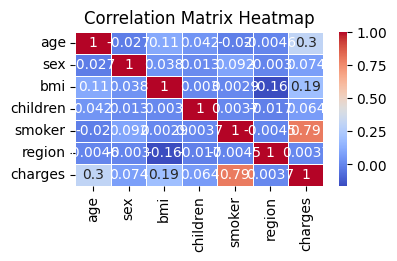

In [ ]:
#Generar estadísticas de los datos y matriz de correlación

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
import chardet

#Estadísticas
# Calcular estadísticas descriptivas
df_stats = df1.describe(include='all')

# Formatear el DataFrame para mostrar sin decimales las variables numéricas
df_stats_formatted = df_stats.copy()


# Rellenar los valores NaN con cadena vacía en el DataFrame de estadísticas formateadas
df_stats_formatted.fillna('', inplace=True)

df_describe_reset = df1.describe().reset_index()
df_describe_reset_transpuesto = df_describe_reset.transpose()
df_describe_transpuesto = df1.describe().transpose()
df_describe_transpuesto_final = df_describe_transpuesto.copy()

# Calcular el rango, varianza y coeficiente de variación
df_describe_transpuesto_final['range'] = df_describe_transpuesto_final['max'] - df_describe_transpuesto_final['min']
df_describe_transpuesto_final['variance'] = df_describe_transpuesto_final['std'] ** 2
df_describe_transpuesto_final['variation_coef'] = df_describe_transpuesto_final['std'] / df_describe_transpuesto_final['mean']
# Seleccionar solo las columnas numéricas que no son varianza ni coeficiente de variación
numeric_columns_1 = df_describe_transpuesto_final.select_dtypes(include=[np.number]).columns
numeric_columns_to_format = numeric_columns_1.difference(['variance', 'variation_coef'])
# Aplicar el formato solo a las columnas seleccionadas
df_describe_transpuesto_final[numeric_columns_to_format] = df_describe_transpuesto_final[numeric_columns_to_format].applymap(lambda x: f'{int(x):,}' if not pd.isna(x) else x)
# Imprimir el DataFrame formateado
print("\033[1;35m")
print('Estadísticas con rango, varianza y coeficiente de variación')
print ("\033[0;30m")
print(df_describe_transpuesto_final)


# Calcular la matriz de correlación
correlation_matrix = df1.corr()

# Imprimir la matriz de correlación
print()
print("\033[1;35m")
print("Matrix de correlación:")
print ("\033[0;30m")
print(correlation_matrix)

# Visualizar la matriz de correlación utilizando un heatmap
print()
plt.figure(figsize=(4, 2))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
print("\033[1;35m")
plt.title('Correlation Matrix Heatmap')
print ("\033[0;30m")
plt.show()

### Análisis de la matriz de correlación

En anterior gráfico de la matriz de correlación sugiere que los factores influyentes en el costo del seguro médico son fumar, seguido por edad y BMI. El género y la región tienen una influencia mínima.

In [ ]:
#Eliminar filas duplicadas
#df1 = df.copy() se comenta porque antes se hizo la copia

#n_dup = len(df1) - len(df1.drop_duplicates())

#print(f"Number of duplicate rows: {n_dup}")

#if n_dup > 0:
   # Eliminar filas duplicadas
#   df = df1.drop_duplicates()
#   n_dup = len(df1) - len(df1.drop_duplicates())
#   print(f"Number of duplicate rows: {n_dup}")

In [ ]:
# Revisar cuántos valores hay por clase

counts = df["sex"].value_counts()
print (counts)
#plt.pie(counts, labels=list(counts.index), autopct="%2.f" )

sex
male      1533
female    1505
Name: count, dtype: int64


In [ ]:
#Convertir el DataFrame df1 en un array de NumPy.

dataset = df1.values
dataset

array([[1.90000000e+01, 0.00000000e+00, 2.79000000e+01, ...,
        1.00000000e+00, 0.00000000e+00, 1.68849240e+04],
       [1.80000000e+01, 1.00000000e+00, 3.37700000e+01, ...,
        0.00000000e+00, 1.00000000e+00, 1.72555230e+03],
       [2.80000000e+01, 1.00000000e+00, 3.30000000e+01, ...,
        0.00000000e+00, 1.00000000e+00, 4.44946200e+03],
       ...,
       [5.90000000e+01, 0.00000000e+00, 2.65050000e+01, ...,
        0.00000000e+00, 3.00000000e+00, 1.28154449e+04],
       [6.10000000e+01, 0.00000000e+00, 2.20400000e+01, ...,
        0.00000000e+00, 3.00000000e+00, 1.36163586e+04],
       [5.30000000e+01, 0.00000000e+00, 3.59000000e+01, ...,
        0.00000000e+00, 0.00000000e+00, 1.11635680e+04]])

In [ ]:
X = dataset[:,0:6]
X

array([[19.   ,  0.   , 27.9  ,  0.   ,  1.   ,  0.   ],
       [18.   ,  1.   , 33.77 ,  1.   ,  0.   ,  1.   ],
       [28.   ,  1.   , 33.   ,  3.   ,  0.   ,  1.   ],
       ...,
       [59.   ,  0.   , 26.505,  0.   ,  0.   ,  3.   ],
       [61.   ,  0.   , 22.04 ,  0.   ,  0.   ,  3.   ],
       [53.   ,  0.   , 35.9  ,  2.   ,  0.   ,  0.   ]])

In [ ]:
Y = dataset[:,6]
Y

array([16884.924  ,  1725.5523 ,  4449.462  , ..., 12815.44495,
       13616.3586 , 11163.568  ])

#Paso 3: Escalamiento de los datos

In [ ]:
from sklearn import preprocessing

min_max_scaler = preprocessing.MinMaxScaler()
X_scale = min_max_scaler.fit_transform(X)
X_scale

array([[0.02173913, 0.        , 0.3212268 , 0.        , 1.        ,
        0.        ],
       [0.        , 1.        , 0.47914985, 0.2       , 0.        ,
        0.33333333],
       [0.2173913 , 1.        , 0.45843422, 0.6       , 0.        ,
        0.33333333],
       ...,
       [0.89130435, 0.        , 0.28369653, 0.        , 0.        ,
        1.        ],
       [0.93478261, 0.        , 0.16357277, 0.        , 0.        ,
        1.        ],
       [0.76086957, 0.        , 0.53645413, 0.4       , 0.        ,
        0.        ]])

In [ ]:
Y_scale = min_max_scaler.fit_transform(Y.reshape(-1, 1)  )
Y_scale

array([[0.25161076],
       [0.00963595],
       [0.05311516],
       ...,
       [0.18665349],
       [0.19943772],
       [0.16028613]])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val_and_test, Y_train, Y_val_and_test = train_test_split(X_scale, Y_scale, test_size=0.3)


In [ ]:
X_val, X_test, Y_val, Y_test = train_test_split(X_val_and_test, Y_val_and_test, test_size=0.5)

# Eliminar una fila específica (por ejemplo, la primera fila)
X_test = np.delete(X_test, 0, axis=0)
Y_test = np.delete(Y_test, 0, axis=0)

print("Longitud de Y_test:", len(Y_test))
print("Longitud de Y_val:", len(Y_val))
print("Longitud de Y_train:", len(Y_train))

Longitud de Y_test: 455
Longitud de Y_val: 456
Longitud de Y_train: 2126


In [ ]:
print(X_train.shape, X_val.shape, X_test.shape, Y_train.shape, Y_val.shape, Y_test.shape)

(2126, 6) (456, 6) (455, 6) (2126, 1) (456, 1) (455, 1)


#Paso 4:Construcción del Modelo

La arquitectura inicial a implementar es la siguiente:

*   Capa oculta 1: 32 neuronas, activación ReLU
*   Capa oculta 2: 16 neuronas, activación ReLU
*   Capa de salida: 1 neurona, activación Sigmoidea

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Definir el modelo secuencial
model = Sequential()

# Agregar las capas
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))  # Primera capa oculta
model.add(Dense(16, activation='relu'))  # Segunda capa oculta
model.add(Dense(1, activation='linear'))  # Capa de salida (ajusta según tu problema)

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])  # Para regresión se usa 'mse', para clasificación se usa 'categorical_crossentropy' o 'binary_crossentropy'


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Paso 5: Entrenamiento del Modelo

In [ ]:
# Asegurarse de que y_train y y_test tengan la forma correcta
Y_train = Y_train.ravel()
Y_test = Y_test.ravel()

#Entrenar el modelo
model.fit(X_train, Y_train)

67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0019 - loss: 0.0383


# Paso 6: Predicción del Modelo

In [ ]:
#Realizar predicciones del modelo en el conjunto de prueba
Y_pred = model.predict(X_test)
#print (Y_test)
#print(Y_pred)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


#Paso 7: Graficas y evaluación del Modelo

Longitud de Y_test: 455
Longitud de Y_pred: 455
Longitud de Y_train: 2126
R^2 score =  0.7055878566698668
Mean Squared Error =  0.008787830952915188
Root Mean Squared Error =  0.09374343151877462
Mean Absolute Error =  0.06460409114887518


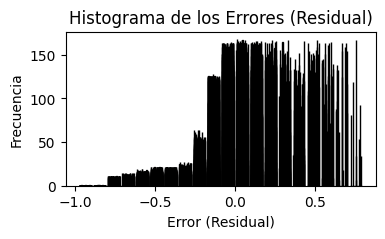

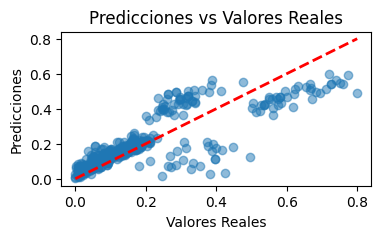

In [ ]:
# Evaluar el modelo

# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error  # Importar métricas de regresión

print("Longitud de Y_test:", len(Y_test))
print("Longitud de Y_pred:", len(Y_pred))
print("Longitud de Y_train:", len(Y_train))

# Asegurarse de que las longitudes sean iguales
assert len(Y_test) == len(Y_pred), "Las longitudes de Y_test y Y_val deben ser iguales"

# Evaluar el modelo con métricas de regresión
r2 = r2_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(Y_test, Y_pred)

print('R^2 score = ', r2)
print('Mean Squared Error = ', mse)
print('Root Mean Squared Error = ', rmse)
print('Mean Absolute Error = ', mae)

# Calcular los errores (residuales)
error = Y_test - Y_val

# Mostrar el histograma de los errores
plt.figure(figsize=(4, 2))  # Reducir el tamaño de la figura
plt.hist(error, bins=20, edgecolor='black')
plt.xlabel('Error (Residual)')
plt.ylabel('Frecuencia')
plt.title('Histograma de los Errores (Residual)')
plt.show()

# Visualización de las predicciones vs valores reales
plt.figure(figsize=(4, 2))  # Reducir el tamaño de la figura
plt.scatter(Y_test, Y_pred, alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.show()

###Visualización de pérdidas y precisión

Un buen modelo es aquel en el que los errores de los conjuntos de prueba y entrenamiento son muy similares y se encuentran en su punto más bajo.

In [ ]:
hist = model.fit(X_train, Y_train,
                 epochs=30,
                 validation_data=(X_val, Y_val))

Epoch 1/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0032 - loss: 0.0109 - val_accuracy: 0.0022 - val_loss: 0.0091
Epoch 2/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0016 - loss: 0.0095 - val_accuracy: 0.0022 - val_loss: 0.0085
Epoch 3/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0027 - loss: 0.0081 - val_accuracy: 0.0022 - val_loss: 0.0077
Epoch 4/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0020 - loss: 0.0081 - val_accuracy: 0.0022 - val_loss: 0.0073
Epoch 5/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0026 - loss: 0.0071 - val_accuracy: 0.0022 - val_loss: 0.0073
Epoch 6/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0021 - loss: 0.0065 - val_accuracy: 0.0022 - val_loss: 0.0069
Epoch 7/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0037 - loss: 0.0069 - val_accuracy: 0.0022 - val_loss: 0.0067
Epoch 8/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0020 - loss: 0.0064 - val_accuracy: 0.0022 - val_loss:

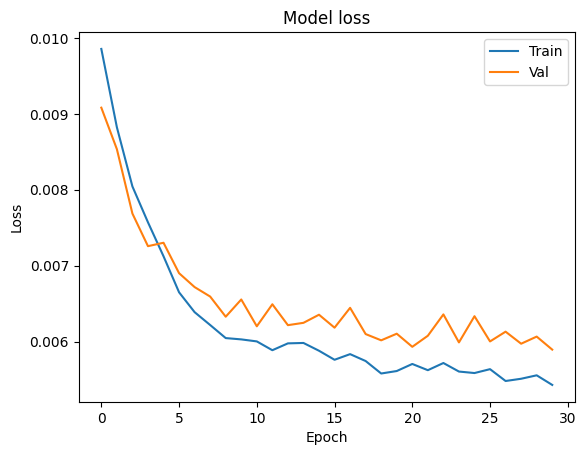

In [ ]:
import matplotlib.pyplot as plt

plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

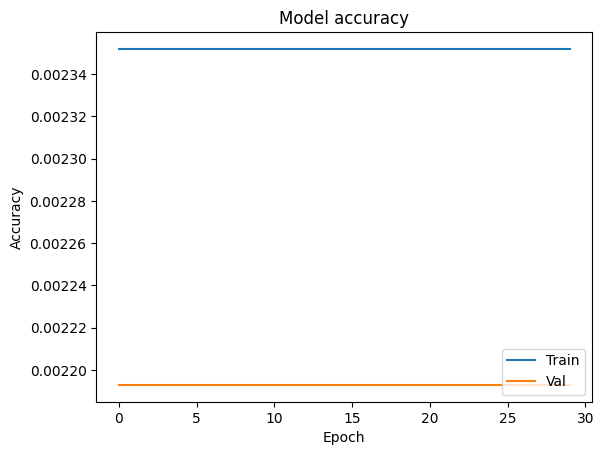

In [ ]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

#Paso 8: Ajuste del modelo y parámetros

###Modificación 1

En una primera corrida, se ajusta la arquitectura inicial aumentando el número de neuronas de 16 a 32 en la capa oculta 2. De esta manera, el modelo es:

*   Capa oculta 1: 32 neuronas, activación ReLU
*   Capa oculta 2: 32 neuronas, activación ReLU
*   Capa de salida: 1 neurona, activación Sigmoidea

In [ ]:
#Instalar scikeras si no está instalado
!pip install --upgrade scikit-learn

In [ ]:
import sklearn
print(sklearn.__version__)

1.3.2


ascii
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
sex
1    1533
0    1505
Name: count, dtype: int64
Longitud de Y_test: 455
Longitud de Y_val: 456
Longitud de Y_train: 2126
Longitud de X_train: 2126
Longitud de y_train: 2126
Longitud de X_test: 455
Longitud de y_test: 455
Dimensiones de X_train: (456, 6)
Dimensiones de y_train: (456, 1)
Dimensiones de X_test: (455, 6)
Dimensiones de y_test: (455, 1)

Iteration 1, loss = 0.04658092
Iteration 2, loss = 0.02174458
Iteration 3, loss = 0.01659869
Iteration 4, loss = 0.01186865
Iteration 5, loss = 0.00902329
Iteration 6, loss = 0.00705697
Iteration 7, loss = 0.00599130
Iteration 8, loss = 0.00545798
Iteratio

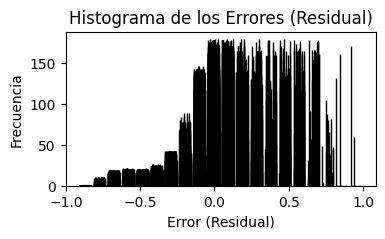

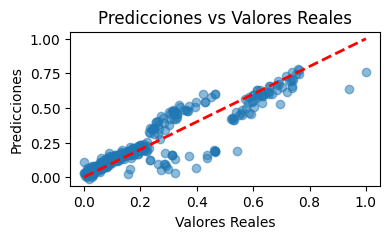

In [ ]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
#from scikeras.wrappers import KerasRegressor
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error  # Importar métricas de regresión
import chardet

# Detectar la codificación del archivo
with open('Medical Insurance Dataset.csv', 'rb') as file:
    result = chardet.detect(file.read(10000))  # Leer una parte del archivo para detectar la codificación
    print(result['encoding'])

# Determinar el número total de líneas en el archivo
with open('Medical Insurance Dataset.csv', 'r', encoding=result['encoding']) as file:
    total_lines = sum(1 for line in file)

# Crea una lista de índices de filas a omitir
# En este caso no fue necesario
skip_rows = []

# Lee el archivo omitiendo la línea específica
df = pd.read_csv('Medical Insurance Dataset.csv',
                 encoding=result['encoding'],
                 delimiter=',',
                 skiprows=skip_rows)

# Verifica el DataFrame
print(df.head())

#Any missing values?
df.isnull().sum()

df1 = df.copy()

# reemplazar la columna sex por números para el clasificador
df1["sex"] = df1["sex"].replace({"female": 0, "male": 1})
# reemplazar la columna smoker por números para el clasificador
df1["smoker"] = df1["smoker"].replace({"no": 0, "yes": 1})
# reemplazar la columna region por números para el clasificador
df1["region"] = df1["region"].replace({"southwest": 0, "southeast": 1, "northwest": 2, "northeast": 3})
df1.head()

#Identificar duplicados
#df1 = df.copy() se comenta porque antes se hizo la copia
#n_dup = len(df1) - len(df1.drop_duplicates())
#print(f"Number of duplicate rows: {n_dup}")

#if n_dup > 0:
#   # Eliminar filas duplicadas
#   df2 = df1.drop_duplicates()
#   n_dup = len(df1) - len(df1.drop_duplicates())
#   print(f"Number of duplicate rows: {n_dup}")

# revisar cuántos valores hay por cada clase
counts = df1["sex"].value_counts()
print (counts)
#plt.pie(counts, labels=list(counts.index), autopct="%2.f" )

# Escalar datos
dataset = df1.values
X = dataset[:,0:6]
Y = dataset[:, 6]
min_max_scaler = preprocessing.MinMaxScaler()
X_scale = min_max_scaler.fit_transform(X)
Y_scale = min_max_scaler.fit_transform(Y.reshape(-1, 1)  )

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_val_and_test, Y_train, Y_val_and_test = train_test_split(X_scale, Y_scale, test_size=0.3)
X_val, X_test, Y_val, Y_test = train_test_split(X_val_and_test, Y_val_and_test, test_size=0.5)

# Eliminar una fila específica (por ejemplo, la primera fila)
X_test = np.delete(X_test, 0, axis=0)
Y_test = np.delete(Y_test, 0, axis=0)

print("Longitud de Y_test:", len(Y_test))
print("Longitud de Y_val:", len(Y_val))
print("Longitud de Y_train:", len(Y_train))
print(f"Longitud de X_train: {len(X_train)}")
print(f"Longitud de y_train: {len(Y_train)}")
print(f"Longitud de X_test: {len(X_test)}")
print(f"Longitud de y_test: {len(Y_test)}")

# Ejemplo de verificación de dimensiones antes de GridSearchCV
print(f"Dimensiones de X_train: {X_val.shape}")
print(f"Dimensiones de y_train: {Y_val.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_test: {Y_test.shape}")
print()

model = MLPRegressor(hidden_layer_sizes=(32, 32),
                     activation='relu',
                     solver='adam',
                     max_iter=100,
                     random_state=42,
                     verbose=True)

# Asegurarse de que y_train y y_test tengan la forma correcta
Y_train = Y_train.ravel()
Y_test = Y_test.ravel()

#Entrenar el modelo
model.fit(X_train, Y_train)

#Realizar predicciones del modelo en el conjunto de prueba
Y_pred = model.predict(X_test)

# Evaluar el modelo

print("Longitud de Y_test:", len(Y_test))
print("Longitud de Y_pred:", len(Y_pred))
print("Longitud de Y_train:", len(Y_train))

# Asegurarse de que las longitudes sean iguales
assert len(Y_test) == len(Y_pred), "Las longitudes de Y_test y Y_val deben ser iguales"

#Calcula la precisión del modelo
#accuracy = accuracy_score(Y_test, Y_pred)
#print("Precisión del modelo (Accuracy):", accuracy)

# Evaluar el modelo con métricas de regresión
r2 = r2_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(Y_test, Y_pred)

print('R^2 score = ', r2)
print('Mean Squared Error = ', mse)
print('Root Mean Squared Error = ', rmse)
print('Mean Absolute Error = ', mae)

# Calcular los errores (residuales)
error = Y_test - Y_val

# Mostrar el histograma de los errores
plt.figure(figsize=(4, 2))  # Reducir el tamaño de la figura
plt.hist(error, bins=20, edgecolor='black')
plt.xlabel('Error (Residual)')
plt.ylabel('Frecuencia')
plt.title('Histograma de los Errores (Residual)')
plt.show()

# Visualización de las predicciones vs valores reales
plt.figure(figsize=(4, 2))  # Reducir el tamaño de la figura
plt.scatter(Y_test, Y_pred, alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.show()

In [ ]:
!pip install tensorflow

### Modificación 2
Se prueban varias opciones de la arquitectura, definiendo:

* optimizers = ['adam', 'rmsprop', 'sgd']
* hidden_layer_sizes = [(32, 32), (64, 32), (64,64), (128,64),(128,128), (256,128), (256,256), (512,256), (512,512)]
* activations = ['relu', 'sigmoid']
* epochs = [20, 30, 40, 50]

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
import chardet

# Detectar la codificación del archivo
with open('Medical Insurance Dataset.csv', 'rb') as file:
    result = chardet.detect(file.read(10000))  # Leer una parte del archivo para detectar la codificación
    print(result['encoding'])

# Determinar el número total de líneas en el archivo
with open('Medical Insurance Dataset.csv', 'r', encoding=result['encoding']) as file:
    total_lines = sum(1 for line in file)

# Crear una lista de índices de filas a omitir
# Resta 1 a 35903 porque skiprows es basado en índices de 0 (0-indexed)
skip_rows = []

# Leer el archivo omitiendo la línea específica
df = pd.read_csv('Medical Insurance Dataset.csv',
                 encoding=result['encoding'],
                 delimiter=',',
                 skiprows=skip_rows)

# Verificar el DataFrame
print(df.head())

#Determinar faltantes
df.isnull().sum()

df1 = df.copy()

# reemplazar la columna sex por números para el clasificador
df1["sex"] = df1["sex"].replace({"female": 0, "male": 1})
# reemplazar la columna smoker por números para el clasificador
df1["smoker"] = df1["smoker"].replace({"no": 0, "yes": 1})
# reemplazar la columna region por números para el clasificador
df1["region"] = df1["region"].replace({"southwest": 0, "southeast": 1, "northwest": 2, "northeast": 3})
df1.head()

# revisar cuántos valores hay por cada clase
counts = df1["sex"].value_counts()
print (counts)
#plt.pie(counts, labels=list(counts.index), autopct="%2.f" )

# Escalar datos
dataset = df1.values
X = dataset[:, 0:6]
Y = dataset[:, 6].astype(float)  # Asegurar que Y sea tipo float

scaler = MinMaxScaler()
X_scale = scaler.fit_transform(X)
Y_scale = scaler.fit_transform(Y.reshape(-1, 1)).flatten()  # Flatten para asegurar una dimensión correcta

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(X_scale, Y_scale, test_size=0.2, random_state=42)

# Definir una función para crear el modelo
def create_model(optimizer='adam', hidden_layer_sizes=(32, 32), activation='relu'):
    model = Sequential()
    model.add(Dense(hidden_layer_sizes[0], activation=activation, input_shape=(X_train.shape[1],)))
    for units in hidden_layer_sizes[1:]:
        model.add(Dense(units, activation=activation))
    model.add(Dense(1))  # Capa de salida para regresión lineal
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['accuracy'])
    return model

# Función para evaluar el modelo con diferentes configuraciones
def evaluate_model(X_train, Y_train, X_test, Y_test, optimizer, hidden_layer_sizes, activation, epochs):
    model = create_model(optimizer=optimizer, hidden_layer_sizes=hidden_layer_sizes, activation=activation)
    model.fit(X_train, Y_train, epochs=epochs, verbose=0)
    Y_pred = model.predict(X_test).flatten()

    # Calcular métricas de evaluación
    accuracy = model.evaluate(X_test, Y_test)[1]
    r2 = r2_score(Y_test, Y_pred)
    mse = mean_squared_error(Y_test, Y_pred)

    return optimizer, hidden_layer_sizes, activation, epochs, accuracy, r2, mse

# Definir configuraciones a probar
optimizers = ['adam', 'rmsprop', 'sgd']
hidden_layer_sizes = [(32, 32), (64, 32), (64,64), (128,64),(128,128), (256,128), (256,256), (512,256), (512,512)]
activations = ['relu', 'sigmoid']
epochs = [20, 30, 40, 50]

# Lista para almacenar resultados
results = []

# Iterar sobre todas las combinaciones de parámetros
for opt in optimizers:
    for hl_sizes in hidden_layer_sizes:
        for act in activations:
            for ep in epochs:
                result = evaluate_model(X_train, Y_train, X_test, Y_test, opt, hl_sizes, act, ep)
                results.append(result)

# Crear un DataFrame para visualizar los resultados
results_df = pd.DataFrame(results, columns=['Optimizer', 'Hidden Layer Sizes', 'Activation', 'Epochs', 'Accuracy', 'R2 Score', 'MSE'])
results_df.sort_values(by='MSE', ascending=True, inplace=True)  # Ordenar por MSE ascendente o la métrica que prefieras

# Mostrar tabla resumen
print("Tabla Resumen de Resultados:")
print(results_df.head(10))  # Mostrar los 10 mejores resultados

# Guardar los resultados en un archivo CSV si deseas
results_df.to_csv('results_summary.csv', index=False)

ascii
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
sex
1    1533
0    1505
Name: count, dtype: int64


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0026 - loss: 0.0067


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0026 - loss: 0.0065      


...

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0024 - loss: 0.0355      


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0024 - loss: 0.0351


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0024 - loss: 0.0344      
Tabla Resumen de Resultados:
    Optimizer Hidden Layer Sizes Activation  Epochs  Accuracy  R2 Score  \
67       adam         (512, 512)       relu      50  0.003289  0.875364   
43       adam         (256, 128)       relu      50  0.003289  0.866370   
131   rmsprop         (512, 256)       relu      50  0.003289  0.863794   
59       adam         (512, 256)       relu      50  0.003289  0.863727   
115   rmsprop         (256, 128)       relu      50  0.003289  0.861854   
57       adam         (512, 256)       relu      30  0.003289  0.861810   
35       adam         (128, 128)       relu      50  0.003289  0.861735   
26       adam          (128, 64)       relu      40  0.003289  0.861639   
34       adam         (128, 128)       relu      40  0.003289  0.861335   
139   rmsprop         (512, 512)       relu      50  0.003289  0.860503   

          MSE  
67   0.004

#Paso 9 Probando con las mejores opciones

In [ ]:
# Definir configuraciones a probar
optimizers = ['rmsprop', 'adam']
hidden_layer_sizes = [(512, 256), (512,512), (1024,512), (1024,1024)]
activations = ['relu']
epochs = [30, 50, 60, 70]

# Lista para almacenar resultados
results = []

# Iterar sobre todas las combinaciones de parámetros
for opt in optimizers:
    for hl_sizes in hidden_layer_sizes:
        for act in activations:
            for ep in epochs:
                result = evaluate_model(X_train, Y_train, X_test, Y_test, opt, hl_sizes, act, ep)
                results.append(result)

# Crear un DataFrame para visualizar los resultados
results_df_rn = pd.DataFrame(results, columns=['Optimizer', 'Hidden Layer Sizes', 'Activation', 'Epochs', 'Accuracy', 'R2 Score', 'MSE'])
results_df_rn.sort_values(by='MSE', ascending=True, inplace=True)  # Ordenar por MSE ascendente o la métrica que prefieras

# Mostrar tabla resumen
print("Tabla Resumen de Resultados:")
print(results_df_rn.head(10))  # Mostrar los 10 mejores resultados

# Guardar los resultados en un archivo CSV si deseas
results_df_rn.to_csv('results_summary.csv', index=False)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0026 - loss: 0.0067      


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0026 - loss: 0.0062      


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0026 - loss: 0.0067


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0026 - loss: 0.0056


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0026 - loss: 0.0057
Tabla Resumen de Resultados:
   Optimizer Hidden Layer Sizes Activation  Epochs  Accuracy  R2 Score  \
23      adam         (512, 512)       relu      70  0.003289  0.878597   
22      adam         (512, 512)       relu      60  0.003289  0.878374   
26      adam        (1024, 512)       relu      60  0.003289  0.876002   
27      adam        (1024, 512)       relu      70  0.003289  0.875101   
31      adam       (1024, 1024)       relu      70  0.003289  0.874676   
30      adam       (1024, 1024)       relu      60  0.003289  0.873927   
11   rmsprop        (1024, 512)       relu      70  0.003289  0.873819   
18      adam         (512, 256)       relu      60  0.003289  0.872447   
10   rmsprop        (1024, 512)       relu      60  0.003289  0.871824   
2    rmsprop         (512, 256)       relu      60  0.003289  0.869307   

         MSE  
23  0.004560  
22  0.004569  

# Definir nuevas configuraciones a probar

Teniendo en cuenta el resultado anterior, se pruebas nuevas configuraciones con estos parámetror:

* optimizers = ['adam']
* hidden_layer_sizes = [(256,256), (256,512), (512,512), (1024,512)]
* activations = ['relu']
* epochs = [90, 100, 120, 130, 140, 150]

In [ ]:
# Definir configuraciones a probar
optimizers = ['adam']
hidden_layer_sizes = [(256,256), (256,512), (512,512), (1024,512)]
activations = ['relu']
epochs = [90, 100, 120, 130, 140, 150]

# Lista para almacenar resultados
results = []

# Iterar sobre todas las combinaciones de parámetros
for opt in optimizers:
    for hl_sizes in hidden_layer_sizes:
        for act in activations:
            for ep in epochs:
                result = evaluate_model(X_train, Y_train, X_test, Y_test, opt, hl_sizes, act, ep)
                results.append(result)

# Crear un DataFrame para visualizar los resultados
results_df_rn2 = pd.DataFrame(results, columns=['Optimizer', 'Hidden Layer Sizes', 'Activation', 'Epochs', 'Accuracy', 'R2 Score', 'MSE'])
results_df_rn2.sort_values(by='MSE', ascending=True, inplace=True)  # Ordenar por MSE ascendente o la métrica que prefieras

# Mostrar tabla resumen
print("Tabla Resumen de Resultados:")
print(results_df_rn2.head(10))  # Mostrar los 10 mejores resultados

# Guardar los resultados en un archivo CSV si deseas
results_df_rn2.to_csv('results_summary.csv', index=False)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0026 - loss: 0.0058      


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0026 - loss: 0.0050      


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0026 - loss: 0.0043      


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0026 - loss: 0.0038      


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0026 - loss: 0.0042
Tabla Resumen de Resultados:
   Optimizer Hidden Layer Sizes Activation  Epochs  Accuracy  R2 Score  \
22      adam        (1024, 512)       relu     140  0.003289  0.917135   
17      adam         (512, 512)       relu     150  0.003289  0.915749   
10      adam         (256, 512)       relu     140  0.003289  0.914802   
5       adam         (256, 256)       relu     150  0.003289  0.913904   
23      adam        (1024, 512)       relu     150  0.003289  0.908168   
4       adam         (256, 256)       relu     140  0.003289  0.908106   
11      adam         (256, 512)       relu     150  0.003289  0.906051   
21      adam        (1024, 512)       relu     130  0.003289  0.905939   
3       adam         (256, 256)       relu     130  0.003289  0.905749   
15      adam         (512, 512)       relu     130  0.003289  0.903509   

         MSE  
22  0.003113  
17  0.003165  

#Paso 10: Utilizando regularización y Dropout

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.regularizers import l2
import chardet

# Detectar la codificación del archivo
with open('Medical Insurance Dataset.csv', 'rb') as file:
    result = chardet.detect(file.read(10000))  # Leer una parte del archivo para detectar la codificación
    print(result['encoding'])

# Determinar el número total de líneas en el archivo
with open('Medical Insurance Dataset.csv', 'r', encoding=result['encoding']) as file:
    total_lines = sum(1 for line in file)

# Crear una lista de índices de filas a omitir
# En este caso no fue necesario
skip_rows = []

# Leer el archivo omitiendo la línea específica
df = pd.read_csv('Medical Insurance Dataset.csv',
                 encoding=result['encoding'],
                 delimiter=',',
                 skiprows=skip_rows)

# Verificar el DataFrame
print(df.head())

#Identificar valore faltantes
df.isnull().sum()

df1 = df.copy()

# reemplazar la columna sex por números para el clasificador
df1["sex"] = df1["sex"].replace({"female": 0, "male": 1})
# reemplazar la columna smoker por números para el clasificador
df1["smoker"] = df1["smoker"].replace({"no": 0, "yes": 1})
# reemplazar la columna region por números para el clasificador
df1["region"] = df1["region"].replace({"southwest": 0, "southeast": 1, "northwest": 2, "northeast": 3})
df1.head()

# revisae cuántos valores hay por cada clase
counts = df1["sex"].value_counts()
print (counts)
#plt.pie(counts, labels=list(counts.index), autopct="%2.f" )

# Escalar datos
dataset = df1.values
X = dataset[:, 0:6]
Y = dataset[:, 6].astype(float)  # Asegurar que Y sea tipo float

scaler = MinMaxScaler()
X_scale = scaler.fit_transform(X)
Y_scale = scaler.fit_transform(Y.reshape(-1, 1)).flatten()  # Flatten para asegurar una dimensión correcta

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(X_scale, Y_scale, test_size=0.2, random_state=42)

# Definir una función para crear el modelo con regularización y dropout
def create_model(optimizer='adam', hidden_layer_sizes=(32, 32), activation='relu', dropout_rate=0.5, l2_reg=0.01):
    if isinstance(hidden_layer_sizes, int):
        hidden_layer_sizes = (hidden_layer_sizes,)
    model = Sequential()
    model.add(Dense(hidden_layer_sizes[0], activation=activation, input_shape=(X_train.shape[1],), kernel_regularizer=l2(l2_reg)))
    model.add(Dropout(dropout_rate))
    for units in hidden_layer_sizes[1:]:
        model.add(Dense(units, activation=activation, kernel_regularizer=l2(l2_reg)))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation=activation))  # Capa de salida para regresión lineal
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['accuracy'])
    return model


# Función para evaluar el modelo con diferentes configuraciones
def evaluate_model(X_train, Y_train, X_test, Y_test, optimizer, hidden_layer_sizes, activation, epochs, dropout_rate, l2_reg):
    model = create_model(optimizer=optimizer, hidden_layer_sizes=hidden_layer_sizes, activation=activation, dropout_rate=dropout_rate, l2_reg=l2_reg)
    model.fit(X_train, Y_train, epochs=epochs, verbose=0)
    Y_pred = model.predict(X_test).flatten()

    # Calcular métricas de evaluación
    accuracy = model.evaluate(X_test, Y_test)[1]
    r2 = r2_score(Y_test, Y_pred)
    mse = mean_squared_error(Y_test, Y_pred)

    return optimizer, hidden_layer_sizes, activation, epochs, dropout_rate, l2_reg, accuracy, r2, mse

# Definir configuraciones a probar
optimizers = ['adam']
hidden_layer_sizes = [(1024,512), (2048,1024)]
activations = ['relu']
epochs = [130, 140, 145, 150]
dropout_rates = [0.2, 0.25]  # Ejemplo de valores para dropout
l2_regs = [0.01, 0.001]     # Ejemplo de valores para regularización L2

# Lista para almacenar resultados
results = []

# Iterar sobre todas las combinaciones de parámetros
for opt in optimizers:
    for hl_sizes in hidden_layer_sizes:
        for act in activations:
            for ep in epochs:
                for dr in dropout_rates:
                    for l2r in l2_regs:
                        result = evaluate_model(X_train, Y_train, X_test, Y_test, opt, hl_sizes, act, ep, dr, l2r)
                        results.append(result)

# Crear un DataFrame para visualizar los resultados
results_df_rn3 = pd.DataFrame(results, columns=['Optimizer', 'Hidden Layer Sizes', 'Activation', 'Epochs', 'Dropout Rate', 'L2 Regularization', 'Accuracy', 'R2 Score', 'MSE'])
results_df_rn3.sort_values(by='MSE', ascending=True, inplace=True)  # Ordenar por MSE ascendente o la métrica que prefieras

# Mostrar tabla resumen
print("Tabla Resumen de Resultados:")
print(results_df_rn3.head(10))  # Mostrar los 10 mejores resultados

# Guardar los resultados en un archivo CSV si deseas
results_df_rn3.to_csv('results_summary.csv', index=False)

ascii
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
sex
1    1533
0    1505
Name: count, dtype: int64


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0026 - loss: 0.0117


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0026 - loss: 0.0087


...

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0026 - loss: 0.0093


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0026 - loss: 0.0133


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0026 - loss: 0.0094
Tabla Resumen de Resultados:
   Optimizer Hidden Layer Sizes Activation  Epochs  Dropout Rate  \
13      adam        (1024, 512)       relu     150          0.20   
25      adam       (2048, 1024)       relu     145          0.20   
21      adam       (2048, 1024)       relu     140          0.20   
17      adam       (2048, 1024)       relu     130          0.20   
11      adam        (1024, 512)       relu     145          0.25   
19      adam       (2048, 1024)       relu     130          0.25   
23      adam       (2048, 1024)       relu     140          0.25   
3       adam        (1024, 512)       relu     130          0.25   
1       adam        (1024, 512)       relu     130          0.20   
5       adam        (1024, 512)       relu     140          0.20   

    L2 Regularization  Accuracy  R2 Score       MSE  
13              0.001  0.003289  0.837382  0.006109  
2

#Paso 11: Utilizando regresión lineal, logarítmica y polinómica

Aunque el objetivo inicial fue usar Deep Learning, se va hacer prueba con algoritmos de Machine Learning para comparar.




In [ ]:
import pandas as pd
import numpy as np
import chardet

# Detecta la codificación del archivo
with open('Medical Insurance Dataset.csv', 'rb') as file:
    result = chardet.detect(file.read(10000))  # Leer una parte del archivo para detectar la codificación
    #print(result['encoding'])

# Determina el número total de líneas en el archivo
with open('Medical Insurance Dataset.csv', 'r', encoding=result['encoding']) as file:
    total_lines = sum(1 for line in file)

# Crea una lista de índices de filas a omitir
# Resta 1 a 35903 porque skiprows es basado en índices de 0 (0-indexed)
skip_rows = []

# Lee el archivo omitiendo la línea específica
df = pd.read_csv('Medical Insurance Dataset.csv',
                 encoding=result['encoding'],
                 delimiter=',',
                 skiprows=skip_rows)

# Verifica el DataFrame
#print(df.head())

sex
2    1533
1    1505
Name: count, dtype: int64

Estadísticas

               age          sex          bmi     children       smoker  \
count  3038.000000  3038.000000  3038.000000  3038.000000  3038.000000   
mean     39.089862     1.504608    30.700265     1.098749     1.208361   
std      14.121217     0.500061     6.085241     1.215146     0.406203   
min      18.000000     1.000000    15.960000     0.000000     1.000000   
25%      26.000000     1.000000    26.315000     0.000000     1.000000   
50%      39.000000     2.000000    30.400000     1.000000     1.000000   
75%      51.000000     2.000000    34.800000     2.000000     1.000000   
max      64.000000     2.000000    53.130000     5.000000     2.000000   

            region       charges  
count  3038.000000   3038.000000  
mean      2.471034  13335.661423  
std       1.101822  12209.554407  
min       1.000000   1121.873900  
25%       2.000000   4676.641325  
50%       2.000000   9391.346000  
75%       3.000000  168

<ipython-input-2-8fd98b4be5b1>:59: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_describe_transpuesto_final[numeric_columns_to_format] = df_describe_transpuesto_final[numeric_columns_to_format].applymap(lambda x: f'{int(x):,}' if not pd.isna(x) else x)


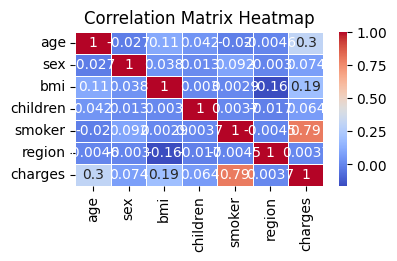

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
import chardet

#Any missing values?
df.isnull().sum()

df1 = df.copy()

# reemplazar la columna sex por números para el clasificador
df1["sex"] = df1["sex"].replace({"female": 1, "male": 2})
# reemplazar la columna smoker por números para el clasificador
df1["smoker"] = df1["smoker"].replace({"no": 1, "yes": 2})
# reemplazar la columna region por números para el clasificador
df1["region"] = df1["region"].replace({"southwest": 1, "southeast": 2, "northwest": 3, "northeast": 4})
df1.head()

# revisar cuántos valores hay por cada clase
counts = df1["sex"].value_counts()
print (counts)
#plt.pie(counts, labels=list(counts.index), autopct="%2.f" )

#Estadísticas
# Calcular estadísticas descriptivas
df_stats = df1.describe(include='all')

# Formatear el DataFrame para mostrar sin decimales las variables numéricas
df_stats_formatted = df_stats.copy()
#numeric_columns = df1.select_dtypes(include=[np.number]).columns
#df_stats_formatted[numeric_columns] = df_stats_formatted[numeric_columns].applymap(lambda x: f'{int(x):,}' if not pd.isna(x) else x)

# Rellenar los valores NaN con cadena vacía en el DataFrame de estadísticas formateadas
df_stats_formatted.fillna('', inplace=True)

print("\033[1;35m")
print("Estadísticas")
print ("\033[0;30m")
print(df_stats_formatted)

df_describe_reset = df1.describe().reset_index()
df_describe_reset_transpuesto = df_describe_reset.transpose()
df_describe_transpuesto = df1.describe().transpose()
df_describe_transpuesto_final = df_describe_transpuesto.copy()

# Calcular el rango, varianza y coeficiente de variación
df_describe_transpuesto_final['range'] = df_describe_transpuesto_final['max'] - df_describe_transpuesto_final['min']
df_describe_transpuesto_final['variance'] = df_describe_transpuesto_final['std'] ** 2
df_describe_transpuesto_final['variation_coef'] = df_describe_transpuesto_final['std'] / df_describe_transpuesto_final['mean']
# Seleccionar solo las columnas numéricas que no son varianza ni coeficiente de variación
numeric_columns_1 = df_describe_transpuesto_final.select_dtypes(include=[np.number]).columns
numeric_columns_to_format = numeric_columns_1.difference(['variance', 'variation_coef'])
# Aplicar el formato solo a las columnas seleccionadas
df_describe_transpuesto_final[numeric_columns_to_format] = df_describe_transpuesto_final[numeric_columns_to_format].applymap(lambda x: f'{int(x):,}' if not pd.isna(x) else x)
# Imprimir el DataFrame formateado
print("\033[1;35m")
print('Estadísticas con rango, varianza y coeficiente de variación')
print ("\033[0;30m")
print(df_describe_transpuesto_final)


# Calcular la matriz de correlación
correlation_matrix = df1.corr()

# Imprimir la matriz de correlación
print()
print("\033[1;35m")
print("Matrix de correlación:")
print ("\033[0;30m")
print(correlation_matrix)

# Visualizar la matriz de correlación utilizando un heatmap
print()
plt.figure(figsize=(4, 2))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
print("\033[1;35m")
plt.title('Correlation Matrix Heatmap')
print ("\033[0;30m")
plt.show()


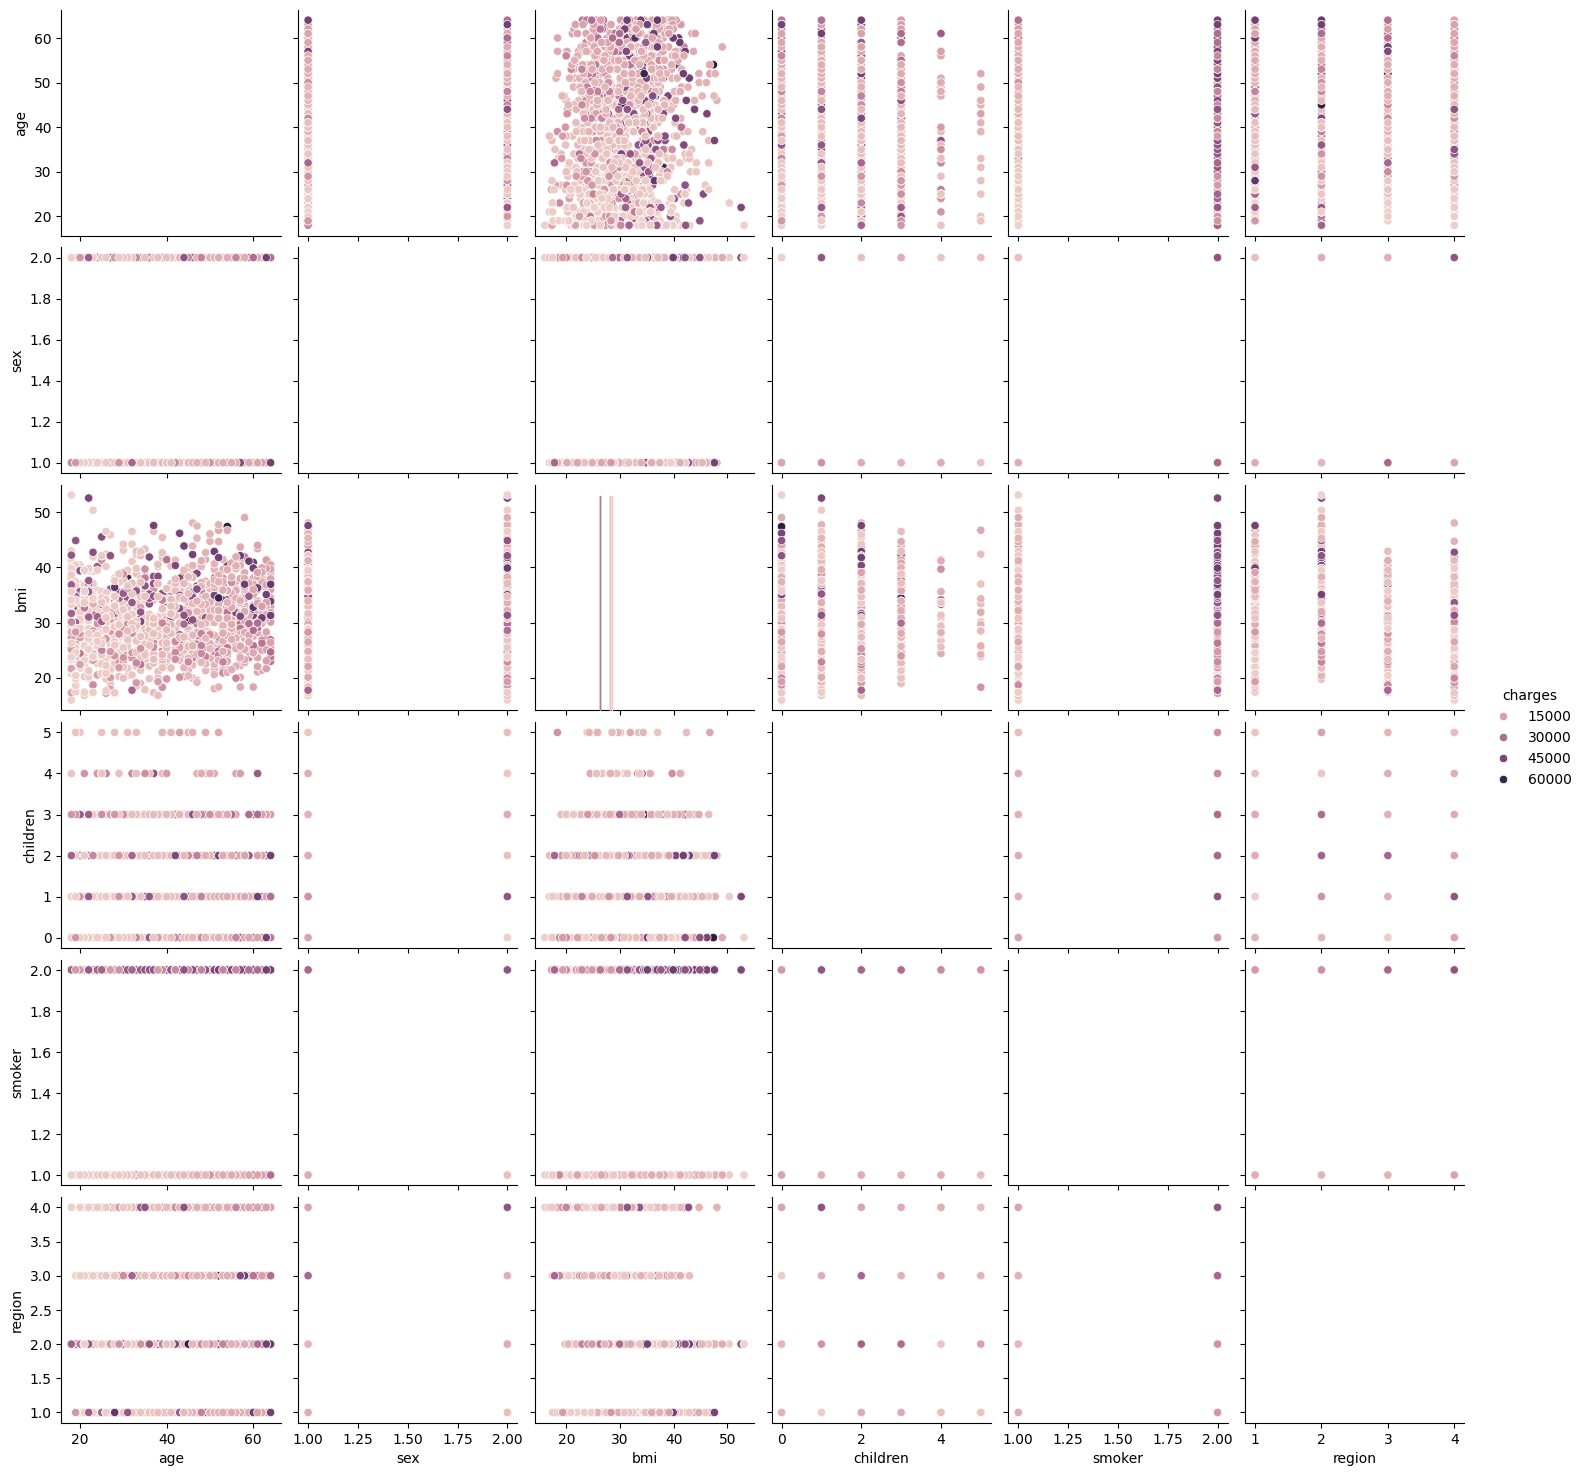

In [ ]:
# visualizando los datos
sns.pairplot(df1, kind= "scatter", hue="charges")
# en el pairplot se puede apreciar que hay correlaciones.

#Regresión lineal

In [ ]:
# Separar las características (variables independientes) y la variable objetivo (dependiente)

X = df1[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
Y = df1['charges']

# Verificar las formas de X,y
print(f"Forma de X: {X.shape}")
print(f"Forma de Y: {Y.shape}")


Forma de X: (3038, 6)
Forma de Y: (3038,)


In [ ]:
# Dividir los datos en conjunto de entrenamiento y conjunto de prueba
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo de regresión lineal múltiple
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)**0.5
r2 = r2_score(y_test, y_pred)
print('modelo = LinearRegression')
print('R^2 Score:', r2)
print('Mean Squared Error (MSE):', mse)
print('Root Mean Squared Error (RMSE):', rmse)


modelo = LinearRegression
R^2 Score: 0.746907719073138
Mean Squared Error (MSE): 37314136.97892561
Root Mean Squared Error (RMSE): 6108.529854140487


In [ ]:
#Ecuación logaritmica
# Leer el archivo Excel
df4 = df.copy()
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3038 entries, 0 to 3037
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       3038 non-null   int64  
 1   sex       3038 non-null   object 
 2   bmi       3038 non-null   float64
 3   children  3038 non-null   int64  
 4   smoker    3038 non-null   object 
 5   region    3038 non-null   object 
 6   charges   3038 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 166.3+ KB


#12.2 Regresión logarítmica

In [ ]:
#Ecuación logaritmica

# Reemplazar la columna sex por números para el clasificador
df4['sex'] = df4['sex'].map({'male': 2, 'female': 3}) # Empieza en 2 para evitar log(0)
# Verificar si hay NaN en la columna 'sex'
if df4['sex'].isnull().any():
    print("Existen valores NaN en la columna 'sex'")
    df4['sex'].fillna(1, inplace=True)  # Rellenar con 1 (o cualquier otro valor)
df4['sex'] = df4['sex'].astype(int) # Convertir a tipo entero

# Reemplazar la columna smoker por números para el clasificador
df4["smoker"] = df4["smoker"].map({"no": 2, "yes": 3}) # Empieza en 2 para evitar log(0)
# Verificar si hay NaN en la columna 'smoker'
if df4['smoker'].isnull().any():
    print("Existen valores NaN en la columna 'smoker'")
    df4['smoker'].fillna(1, inplace=True)  # Rellenar con 1 (o cualquier otro valor)
df4['smoker'] = df4['smoker'].astype(int) # Convertir a tipo entero

# Reemplazar la columna region por números para el clasificador
df4["region"] = df4["region"].map({"southwest": 2, "southeast": 3, "northwest": 4, "northeast": 5}) # Empieza en 2 para evitar log(0)
# Verificar si hay NaN en la columna 'region'
if df4['region'].isnull().any():
    print("Existen valores NaN en la columna 'region'")
    df4['region'].fillna(1, inplace=True)  # Rellenar con 1 (o cualquier otro valor)
df4['region'] = df4['region'].astype(int) # Convertir a tipo entero

# Verificar el DataFrame después de la conversión
df4.info()

# Aplicar la transformación logarítmica solo si no hay valores cero o negativos
df4['age'] = np.log(df4['age'] + 1)
df4['sex'] = np.log(df4['sex'] + 1)
df4['bmi'] = np.log(df4['bmi'] + 1)
df4['children'] = np.log(df4['children'] + 1)
df4['region'] = np.log(df4['region'] + 1)
df4['charges'] = np.log(df4['charges'] + 1)

# Verificar el DataFrame después de la transformación
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3038 entries, 0 to 3037
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       3038 non-null   int64  
 1   sex       3038 non-null   int64  
 2   bmi       3038 non-null   float64
 3   children  3038 non-null   int64  
 4   smoker    3038 non-null   int64  
 5   region    3038 non-null   int64  
 6   charges   3038 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 166.3 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3038 entries, 0 to 3037
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       3038 non-null   float64
 1   sex       3038 non-null   float64
 2   bmi       3038 non-null   float64
 3   children  3038 non-null   float64
 4   smoker    3038 non-null   int64  
 5   region    3038 non-null   float64
 6   charges   3038 non-null   float64
dtypes: float64(6), int64(1)
memor

Tamaño de X: 3038
Tamaño de Y: 3038
Error Cuadrático Medio (MSE): 0.23168382102622004
Raíz del Error Cuadrático Medio (RMSE): 0.4813354558166477
Coeficiente de Determinación (R^2): 0.7315233610535936
Coeficiente del modelo (Log del tamaño en metros cuadrados): 0.4911569462360628
Intercepto del modelo: 9.103880643533712


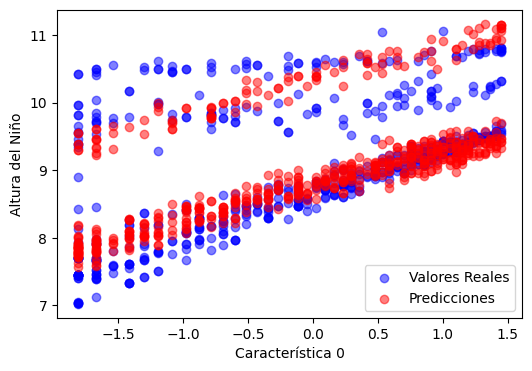

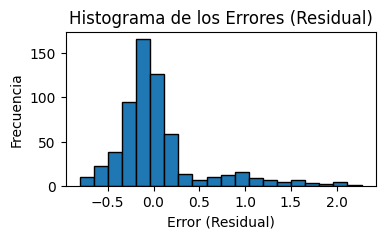

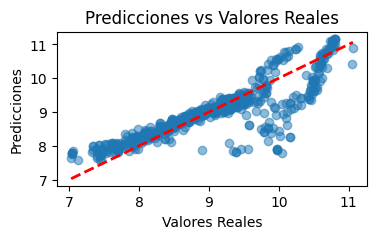

Text(0.5, 1.0, 'histograma de las diferencias')

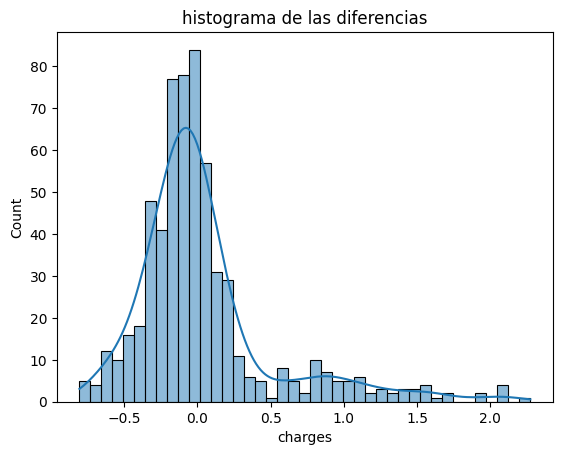

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar las características (variable independiente) y la variable objetivo (dependiente)
X = df4[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
Y = df4['charges']

print(f"Tamaño de X: {len(X)}")
print(f"Tamaño de Y: {len(Y)}")

# Dividir los datos en conjunto de entrenamiento y conjunto de prueba
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Crear y entrenar el modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test_scaled)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)**0.5
r2 = r2_score(y_test, y_pred)

print(f"Error Cuadrático Medio (MSE): {mse}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse}")
print(f"Coeficiente de Determinación (R^2): {r2}")

# Verificar los coeficientes
print(f"Coeficiente del modelo (Log del tamaño en metros cuadrados): {modelo.coef_[0]}")
print(f"Intercepto del modelo: {modelo.intercept_}")

# Elegir una columna específica para graficar
feature_index = 0  # Índice de la columna 'father', puedes cambiar esto a 1, 2, o 3 para otras columnas

# Graficar las predicciones vs los valores reales
plt.figure(figsize=(6, 4))
plt.scatter(X_test_scaled[:, feature_index], y_test, color='blue', alpha=0.5, label='Valores Reales')
plt.scatter(X_test_scaled[:, feature_index], y_pred, color='red', alpha=0.5, label='Predicciones')
plt.xlabel(f'Característica {feature_index}')
plt.ylabel('Altura del Niño')
plt.legend()
plt.show()

# Calcular los errores (residuales)
error = y_test - y_pred

# Mostrar el histograma de los errores
plt.figure(figsize=(4, 2))  # Reducir el tamaño de la figura
plt.hist(error, bins=20, edgecolor='black')
plt.xlabel('Error (Residual)')
plt.ylabel('Frecuencia')
plt.title('Histograma de los Errores (Residual)')
plt.show()

# Visualización de las predicciones vs valores reales
plt.figure(figsize=(4, 2))  # Reducir el tamaño de la figura
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.show()

# Evaluando el modelo con un histograma que grafique la diferencia entre y_test y las predicciones del modelo
sns.histplot(y_test-y_pred, kde=True)
plt.rcParams["figure.figsize"] = (6,4) # Custom figure size in inches
plt.title("histograma de las diferencias")

#Regresión polinómica

In [ ]:
pip install tabulate

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
import chardet

# Detectar la codificación del archivo
with open('Medical Insurance Dataset.csv', 'rb') as file:
    result = chardet.detect(file.read(10000))  # Leer una parte del archivo para detectar la codificación
    print(result['encoding'])

# Determinar el número total de líneas en el archivo
with open('Medical Insurance Dataset.csv', 'r', encoding=result['encoding']) as file:
    total_lines = sum(1 for line in file)

# Crear una lista de índices de filas a omitir
# En este caso no fue necesario
skip_rows = []

# Leer el archivo omitiendo la línea específica
df = pd.read_csv('Medical Insurance Dataset.csv',
                 encoding=result['encoding'],
                 delimiter=',',
                 skiprows=skip_rows)

# Verificar el DataFrame
print(df.head())

#Identificar valores faltantes
df.isnull().sum()

ascii
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Tamaño de X: 3038
Tamaño de Y: 3038
Forma de X: (3038, 6)
Forma de Y: (3038,)
Forma de X_test: (608, 6)
Forma de y_test: (608,)
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
dtype: int64
0


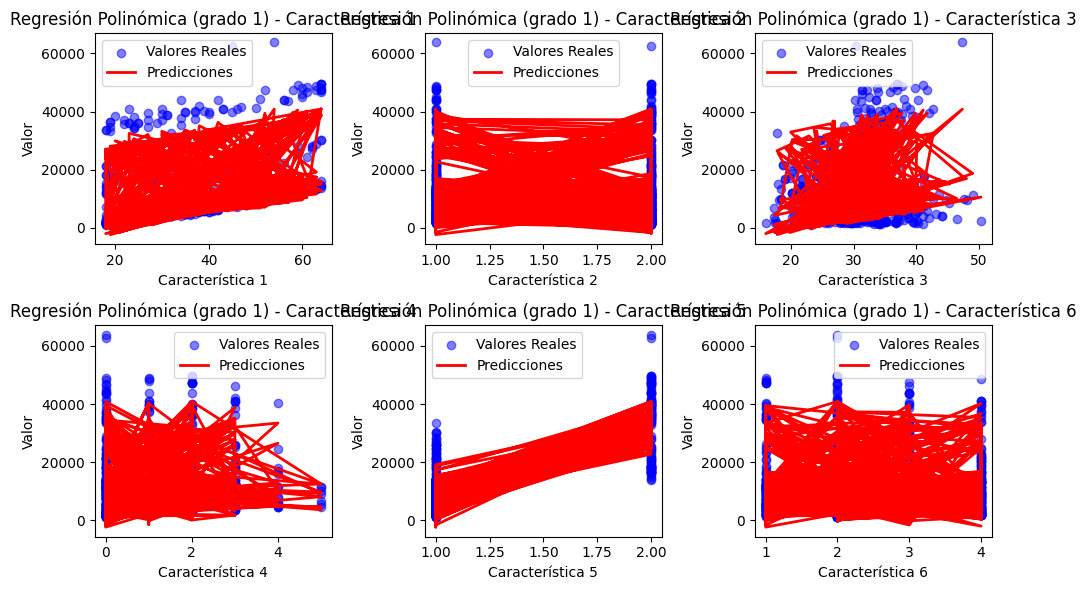

MSE: 37314136.97892563
RMSE: 6108.52985414049
R^2: 0.7469077190731379


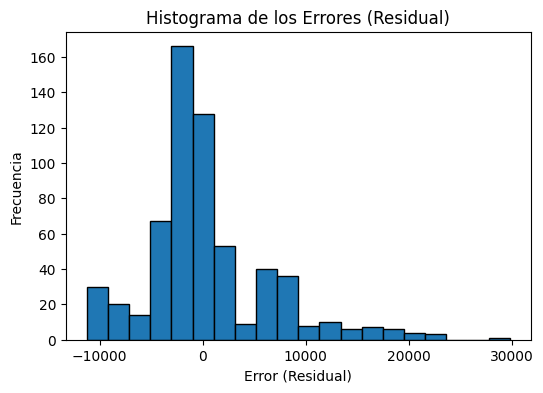

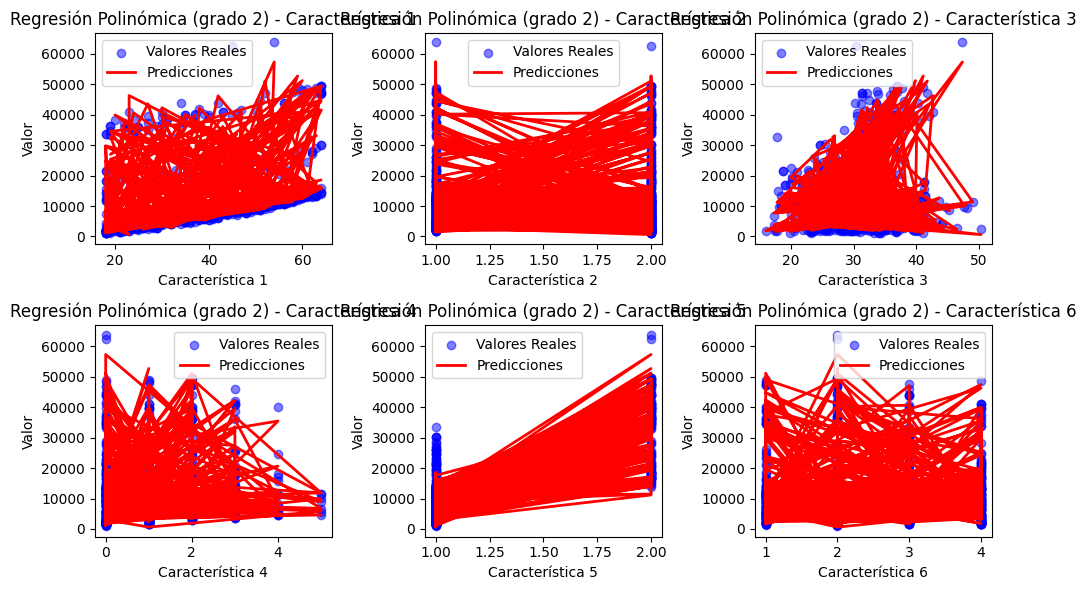

MSE: 23965200.70395683
RMSE: 4895.42650889142
R^2: 0.837450151601788


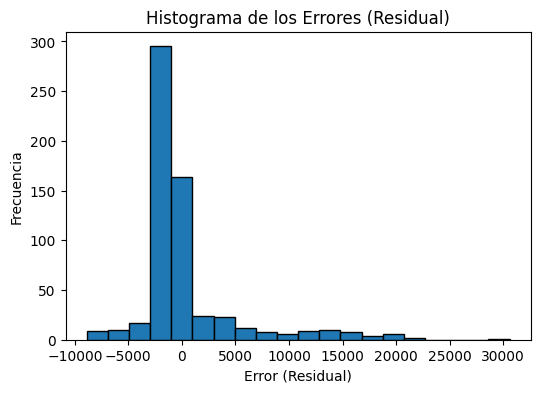

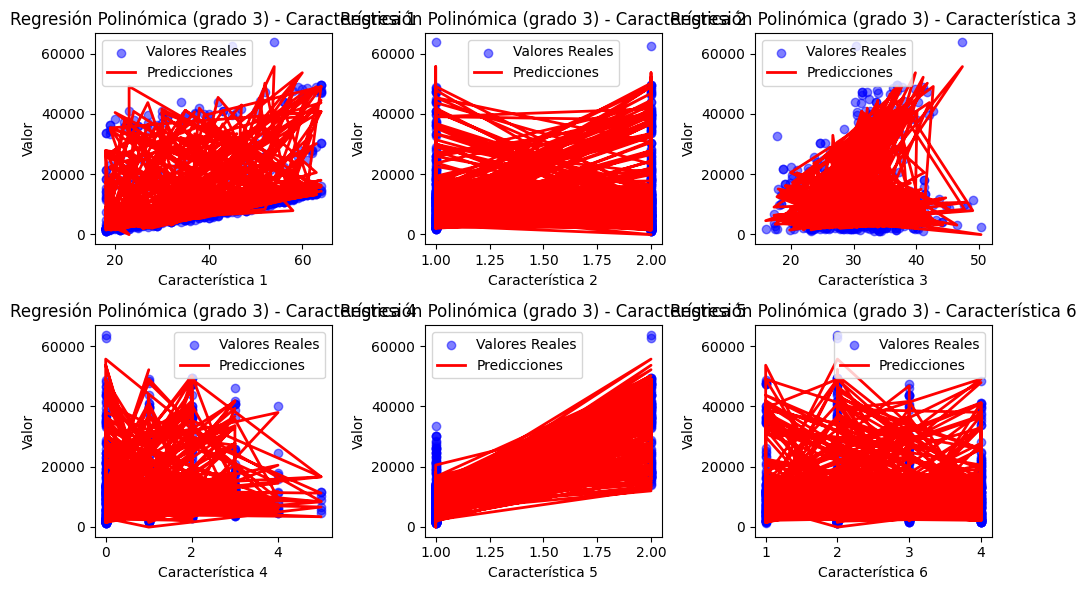

MSE: 23778688.75378642
RMSE: 4876.339688104841
R^2: 0.8387152146237576


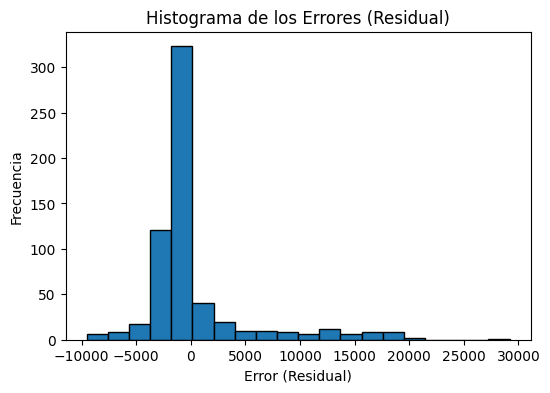

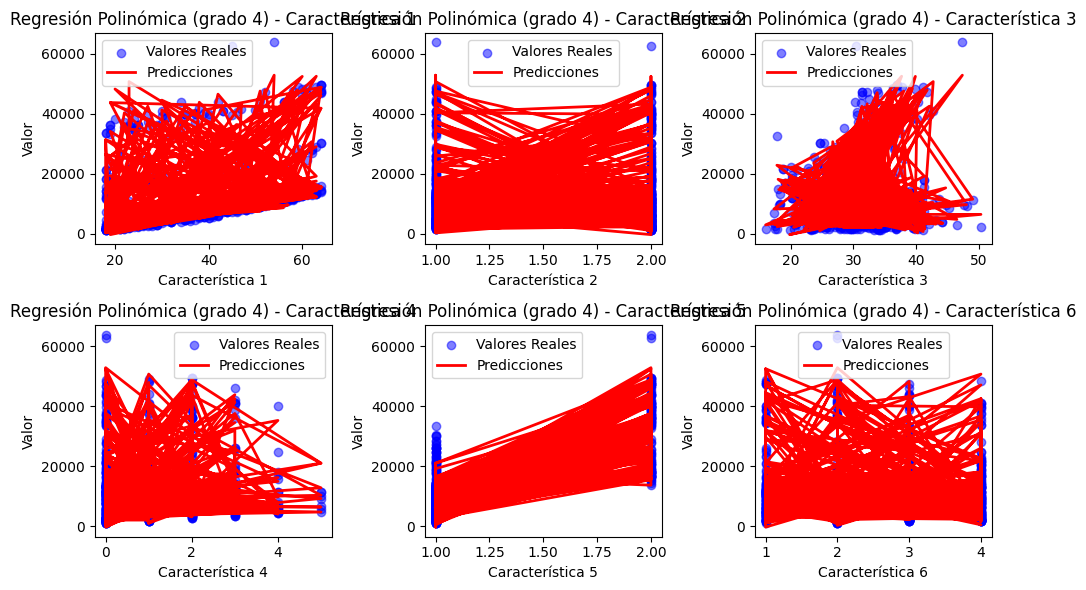

MSE: 23488287.922530264
RMSE: 4846.4716983110775
R^2: 0.84068492944812


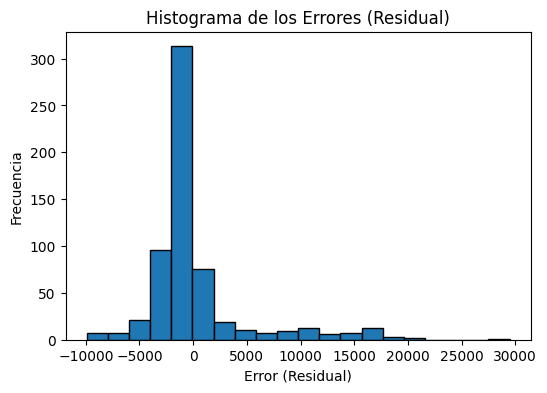

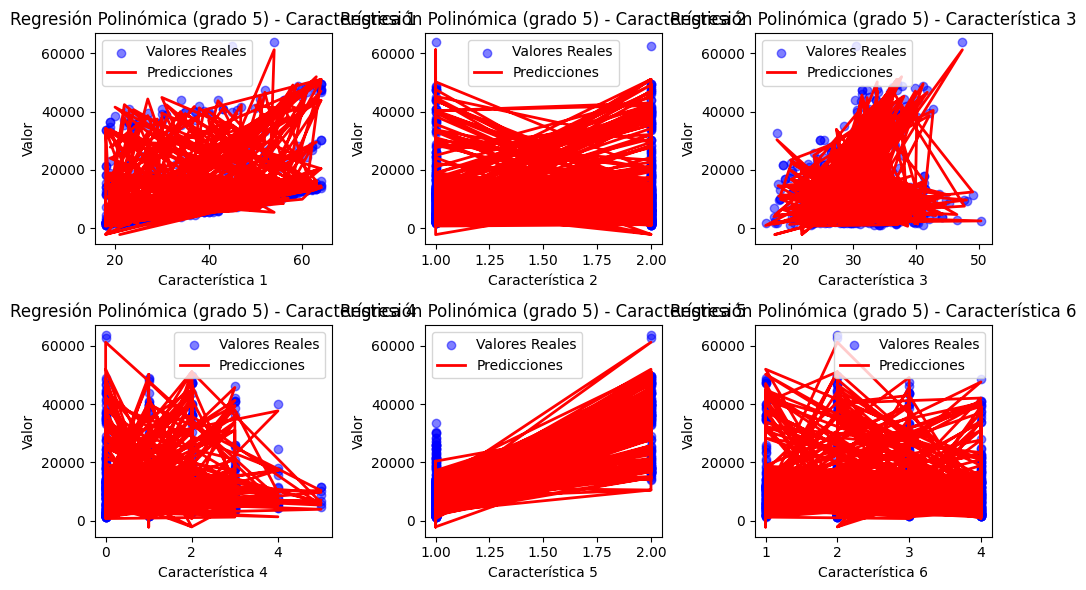

MSE: 22577053.018585075
RMSE: 4751.531649750959
R^2: 0.8468656035564321


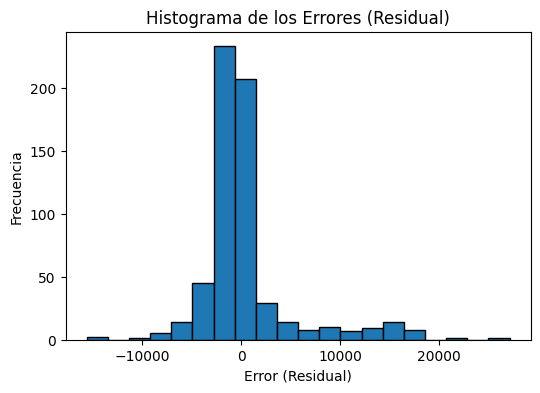

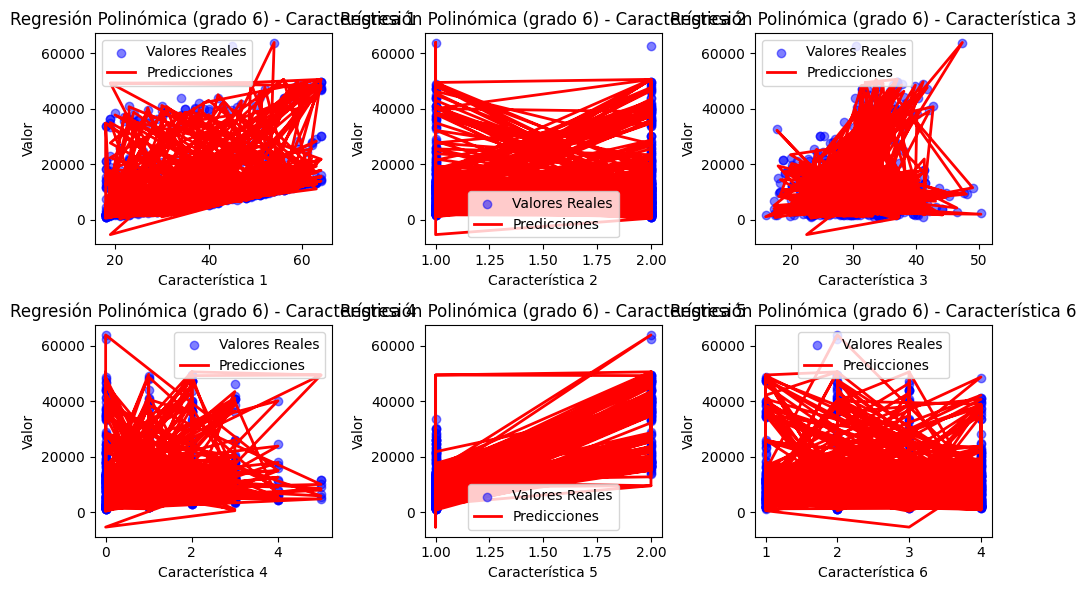

MSE: 24450791.956280433
RMSE: 4944.774206804637
R^2: 0.8341565098992311


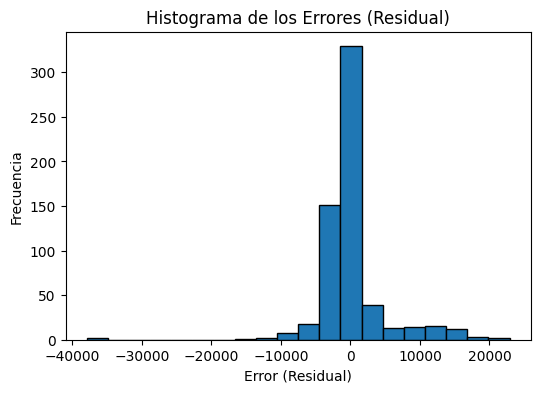

Advertencia: para el grado 7, el valor de R^2 es -7019.044607860662, lo que indica un problema con el modelo.
Tabla de Resultados:
╒══════════╤═══════╤══════════════╤══════════╕
│   Degree │   R^2 │          MSE │     RMSE │
╞══════════╪═══════╪══════════════╪══════════╡
│    1.000 │ 0.747 │ 37314136.979 │ 6108.530 │
├──────────┼───────┼──────────────┼──────────┤
│    2.000 │ 0.837 │ 23965200.704 │ 4895.427 │
├──────────┼───────┼──────────────┼──────────┤
│    3.000 │ 0.839 │ 23778688.754 │ 4876.340 │
├──────────┼───────┼──────────────┼──────────┤
│    4.000 │ 0.841 │ 23488287.923 │ 4846.472 │
├──────────┼───────┼──────────────┼──────────┤
│    5.000 │ 0.847 │ 22577053.019 │ 4751.532 │
├──────────┼───────┼──────────────┼──────────┤
│    6.000 │ 0.834 │ 24450791.956 │ 4944.774 │
╘══════════╧═══════╧══════════════╧══════════╛


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler  # Asegúrate de importar StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tabulate import tabulate

# Crear una copia del DataFrame
df5 = df.copy()

# Reemplazar las columnas categóricas por números
df5["sex"] = df5["sex"].replace({"female": 1, "male": 2})
df5["smoker"] = df5["smoker"].replace({"no": 1, "yes": 2})
df5["region"] = df5["region"].replace({"southwest": 1, "southeast": 2, "northwest": 3, "northeast": 4})


# Separar características y variable objetivo
X = df5[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y = df5['charges']

print(f"Tamaño de X: {len(X)}")
print(f"Tamaño de Y: {len(y)}")

# Verificar las formas de X, y
print(f"Forma de X: {X.shape}")
print(f"Forma de Y: {y.shape}")

# Dividir los datos en conjunto de entrenamiento y conjunto de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Asegurar de que X, y tienen la misma longitud
if len(X) != len(y):
    raise ValueError(f"X e y deben tener la misma longitud. Longitudes actuales: {len(X)}, {len(y)}")

print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_test: {y_test.shape}")

print(X_test.isna().sum())  # Verificar valores NaN en X_test
print(y_test.isna().sum())  # Verificar valores NaN en y_test

def polynomial_plot_2(X, y, degree, results_table):
    # Dividir los datos en conjuntos de entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Transformar las características en características polinómicas
    poly_features = PolynomialFeatures(degree=degree)
    X_train_poly = poly_features.fit_transform(X_train)
    X_test_poly = poly_features.transform(X_test)

    # Entrenar el modelo de regresión lineal con características polinómicas
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predecir en el conjunto de prueba
    y_pred = model.predict(X_test_poly)

    # Calcular métricas de evaluación
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    # Verificar las métricas
    if r2 < 0 or r2 > 1:
        print(f"Advertencia: para el grado {degree}, el valor de R^2 es {r2}, lo que indica un problema con el modelo.")
        return

    # Agregar los resultados a la tabla solo si R^2 es válido
    results_table.append({'Degree': degree, 'R^2': r2, 'MSE': mse, 'RMSE': rmse})

    # Graficar solo si R^2 es válido
    if 0 <= r2 <= 1:
        plt.figure(figsize=(10, 6))

        # Graficar para cada característica
        for i in range(X_test.shape[1]):
            plt.subplot(2, 3, i + 1)  # Crear subgráficas si hay más de una característica

            # Usar .iloc[:, i] si es un DataFrame, y X_test[:, i] si es un array de NumPy
            if isinstance(X_test, pd.DataFrame):
                plt.scatter(X_test.iloc[:, i], y_test, color='blue', alpha=0.5, label='Valores Reales')
                plt.plot(X_test.iloc[:, i], y_pred, color='red', linewidth=2, label='Predicciones')
            else:
                plt.scatter(X_test[:, i], y_test, color='blue', alpha=0.5, label='Valores Reales')
                plt.plot(X_test[:, i], y_pred, color='red', linewidth=2, label='Predicciones')

            plt.xlabel(f'Característica {i + 1}')
            plt.ylabel('Valor')
            plt.title(f'Regresión Polinómica (grado {degree}) - Característica {i + 1}')
            plt.legend()

        plt.tight_layout()
        plt.show()

        print(f"MSE: {mse}")
        print(f"RMSE: {rmse}")
        print(f"R^2: {r2}")

        # Calcular los errores (residuales)
        error = y_test - y_pred

        # Mostrar el histograma de los errores
        plt.figure(figsize=(6, 4))  # Ajustar el tamaño de la figura
        plt.hist(error, bins=20, edgecolor='black')
        plt.xlabel('Error (Residual)')
        plt.ylabel('Frecuencia')
        plt.title('Histograma de los Errores (Residual)')
        plt.show()

# Crear una tabla para almacenar los resultados
results_table = []

# Llamar a la función con X, y don diferentes grados
for degree in [1, 2, 3, 4, 5, 6, 7]:
    polynomial_plot_2(X, y, degree, results_table)

# Convertir la lista de resultados a un DataFrame
results_df_polinomica = pd.DataFrame(results_table)

# Mostrar la tabla de resultados con formato de borde
print("Tabla de Resultados:")
print(tabulate(results_df_polinomica, headers='keys', tablefmt='fancy_grid', showindex=False, floatfmt=".3f"))

# Conclusiones

###Conclusiones de Deep Learning

* Rendimiento Consistente:

La métrica de MSE (Error Cuadrático Medio) es consistente a lo largo de las distintas configuraciones, con valores que oscilan entre 0.003113 y 0.003625. Esto indica que, en general, la red neuronal mantiene un rendimiento estable entre las configuraciones.

* Efectividad del Número de Épocas:

Los resultados muestran una ligera disminución en MSE, un leve incremento en la precisión (Accuracy) y en el R² con un mayor número de épocas. Por tanto, en este caso, la cantidad de épocas tiene un impacto menor en el rendimiento general de los modelos entrenados.

* Impacto de Tamaño de Capa Oculta:

Los modelos con capas ocultas más grandes (por ejemplo, (1024, 512)) tienen el mejor rendimiento en comparación con las capas más pequeñas, con el mejor R² (0.917135). Esto sugiere que el tamaño de la capa oculta se traduce en un mejor ajuste del modelo, aunque es importante tener en cuenta otros factores como la arquitectura.

* Configuración Óptima:

La configuración con el menor MSE es la del modelo con 1024 y 512 unidades en las capas ocultas con 140 épocas (valor de MSE = 0.003113). Sin embargo, la diferencia entre las mejores configuraciones es mínima, por lo que el modelo con menor MSE no tiene una mejora significativa respecto a los demás.

###Conclusiones de Machine Learning

* Rendimiento por Grado del Polinomio:

El rendimiento de los modelos polinómicos mejora con el grado del polinomio, como lo indica el aumento en el R² y la disminución en MSE y RMSE. Esto sugiere que modelos con grados de polinomio mayores capturan mejor la complejidad de este conjunto de datos.

* Mejor Rendimiento con Polinomios de Grado 5:

El polinomio de grado 5 ofrece el mejor R² (0.847) y el menor MSE (22,577,053.019) y RMSE (4751.532). Esto indica que un polinomio de grado 5 es el más eficaz para ajustar el modelo a los datos en comparación con los grados más bajos.

* Posible Sobreajuste:

Aunque el polinomio de grado 6 muestra un R² ligeramente menor y un MSE mayor en comparación con el grado 5, podría estar indicando sobreajuste. Los modelos polinómicos de grado más alto pueden capturar el ruido en los datos, lo que podría resultar en una peor generalización.

### Comparación entre Deep Learning y Machine Learning

* Deep Learning tiende a tener valores de MSE más bajos en comparación con los modelos de Machine Learning polinómicos, lo que sugiere que las redes neuronales profundas pueden ofrecer una mayor precisión en problemas complejos. Así mismo, el mejor R² obtenido con las corridas realizadas (0.917135).

* Machine Learning polinómico muestra mejoras significativas con grados de polinomio mayores, pero también puede enfrentar problemas de sobreajuste.

En resumen, los modelos de Deep Learning parecen tener un rendimiento más estable y consistente, mientras que los modelos polinómicos pueden ofrecer mejor ajuste pero con riesgo de sobreajuste. La elección entre estos enfoques dependerá del contexto específico del problema y de los datos disponibles.

#Referencias

* Escallón Portilla, A. (2024). Talento Tech. Artificial Intellenge (Intermediate) Bootcamp.

* Google. (2024). Gemini. https://colab.research.google.com/

* Moinulhaq.(2024). Medical Insurance Dataset. https://www.kaggle.com/datasets/orhfusion/medical-insurance-dataset?resource=download

* OpenAI. (2024). ChatGPT (agosto 2024) [Modelo GPT-4]. https://chat.openai.com/


# Video

https://youtu.be/t3MtBCaF16E